In [ ]:
# Data Processing
import pandas as pd

In [ ]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [54]:
# Tree Visualisation
from sklearn.tree import export_graphviz
from matplotlib import pyplot as plt
import graphviz

In [4]:
cars = pd.read_csv('data/car.csv')

In [5]:
cars.shape

(1728, 7)

In [6]:
cars.head()

,price,maintenance,doors,seats,storage,safety,shouldBuy
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
cars.describe()

,price,maintenance,doors,seats,storage,safety,shouldBuy
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [8]:
cars.isnull().sum()

price          0
maintenance    0
doors          0
seats          0
storage        0
safety         0
shouldBuy      0
dtype: int64

In [9]:
for col in cars.columns:
    print(f"{col}: {cars[col].nunique()} unique values")
    print(cars[col].unique())
    print()

price: 4 unique values
['vhigh' 'high' 'med' 'low']

maintenance: 4 unique values
['vhigh' 'high' 'med' 'low']

doors: 4 unique values
['2' '3' '4' '5more']

seats: 3 unique values
['2' '4' 'more']

storage: 3 unique values
['small' 'med' 'big']

safety: 3 unique values
['low' 'med' 'high']

shouldBuy: 4 unique values
['unacc' 'acc' 'vgood' 'good']



Text(0.5, 1.0, 'Distribution of shouldBuy')

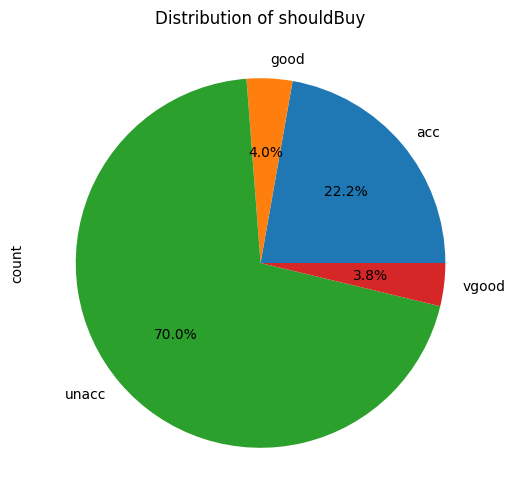

In [55]:
figure = plt.figure(figsize=(8, 6))
cars['shouldBuy'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of shouldBuy')

In [10]:
from sklearn.preprocessing import OrdinalEncoder

# Define the explicit order for every column
categories = [
    ['low', 'med', 'high', 'vhigh'], # 1st: price
    ['low', 'med', 'high', 'vhigh'], # 2nd: maintenance
    ['2', '3', '4', '5more'],        # 3rd: doors
    ['2', '4', 'more'],              # 4th: seats
    ['small', 'med', 'big'],         # 5th: storage
    ['low', 'med', 'high']           # 6th: safety
]

encoder = OrdinalEncoder(categories=categories)
X_encoded = encoder.fit_transform(cars.iloc[:, :-1]) # All columns except target

In [11]:
# Typically for the target (y), we use LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(cars['shouldBuy'])

In [12]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
len(X_train), len(X_test)

(1382, 346)

In [14]:
rf = RandomForestClassifier()

In [15]:
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
y_pred = rf.predict(X_test)

In [88]:
print("Accuracy:", f"{accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9855


In [89]:
print(f"Training Accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {rf.score(X_test, y_test):.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.9855


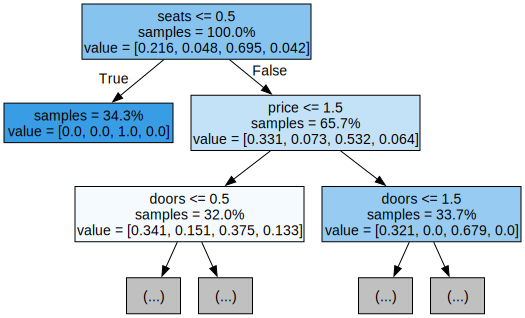

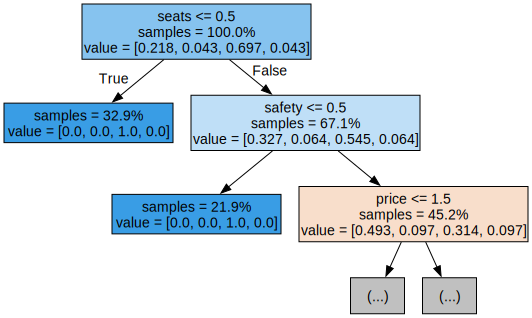

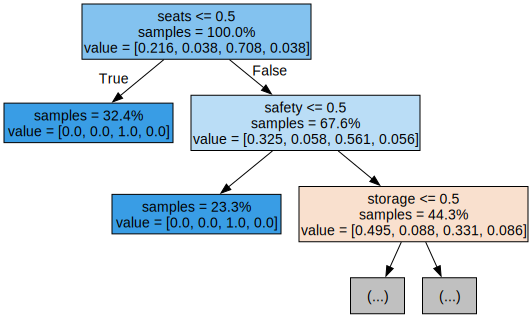

In [19]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=cars.columns[:-1],  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

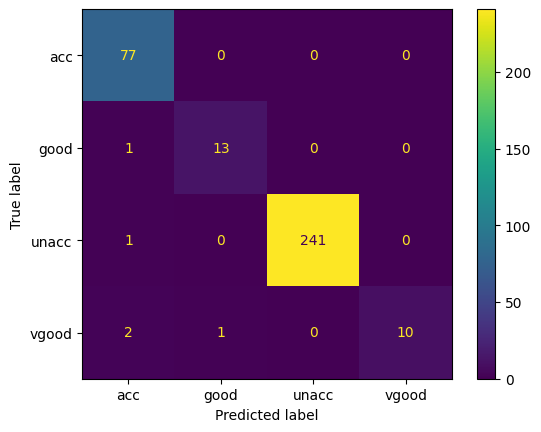

In [86]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

In [87]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", f"{accuracy:.4f}")
print("Precision:", f"{precision:.4f}")
print("Recall:", f"{recall:.4f}")

Accuracy: 0.9855
Precision: 0.9861
Recall: 0.9855


To make the model more robust and less "memorized," you can constrain the growth of the trees. This is called Hyperparameter Tuning.

Try adjusting these three parameters:

- max_depth: Limits how deep each tree can grow.

- min_samples_split: The minimum number of samples required to split a node.

- n_estimators: The number of trees in the forest.

In [22]:
rf1 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,       # Try limiting depth to 10
    min_samples_split=5, # Don't split if a node has very few samples
    random_state=42
)

In [23]:
rf1.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [90]:
print(f"New Training Accuracy: {rf1.score(X_train, y_train):.4f}")
print(f"New Testing Accuracy: {rf1.score(X_test, y_test):.4f}")

New Training Accuracy: 0.9978
New Testing Accuracy: 0.9798


In [25]:
from sklearn.model_selection import cross_val_score

# Use the model you just created
scores = cross_val_score(rf1, X_encoded, y, cv=5)

print(f"All Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

All Scores: [0.72254335 0.83815029 0.76878613 0.85507246 0.82318841]
Average Accuracy: 0.8015
Standard Deviation: 0.0490


This is a significant shift! This result is exactly why Cross-Validation is the "truth serum" of machine learning.

Our previous accuracy (~98%) was likely a result of a "lucky split"—where the specific rows chosen for the test set happened to be very similar to the rows in the training set. Now that we've tested the model across the entire dataset, we see a much more realistic average of 80.15%.

In [ ]:
rf2= RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced', # Automatically adjusts weights based on frequencies
    random_state=42
)

In [27]:
rf2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
print(f"New Training Accuracy: {rf1.score(X_train, y_train):.4f}")
print(f"New Testing Accuracy: {rf1.score(X_test, y_test):.4f}")

New Training Accuracy: 0.9978
New Testing Accuracy: 0.9798


Standard Cross-Validation might accidentally put all vgood samples in the test set and none in the training set. Stratified K-Fold ensures that every single fold has the same 70/22/4/4 ratio as your original pie chart.

In [91]:
from sklearn.model_selection import StratifiedKFold

# This ensures each fold is a mini-replica of your pie chart
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf2, X_encoded, y, cv=skf)

print(f"All Scores: {scores}")
print(f"Average Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")

All Scores: [0.9566474  0.98265896 0.97687861 0.96231884 0.97391304]
Average Accuracy: 0.9705
Standard Deviation: 0.0096


In [63]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_encoded, 
    y, 
    test_size=0.1, 
    shuffle=True, 
    random_state=42, # Ensures reproducibility
    stratify=y  # Maintains the 70/22/4/4 ratio in both sets
)

In [64]:
len(X_train1), len(X_test1)

(1555, 173)

In [69]:
rf3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

In [70]:
rf3.fit(X_train1, y_train1)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
print(f"Post-Shuffle Training Accuracy: {rf3.score(X_train1, y_train1):.4f}")
print(f"Post-Shuffle Testing Accuracy: {rf3.score(X_test1, y_test1):.4f}")

Post-Shuffle Training Accuracy: 0.9775
Post-Shuffle Testing Accuracy: 0.9942


### Hyperparameter Tuning
The code below uses Scikit-Learn’s RandomizedSearchCV, which will randomly search parameters within a range per hyperparameter. We define the hyperparameters to use and their ranges in the param_dist dictionary. In our case, we are using:

- n_estimators: the number of decision trees in the forest. Increasing this hyperparameter generally improves the performance of the model but also increases the computational cost of training and predicting.
- max_depth: the maximum depth of each decision tree in the forest. Setting a higher value for max_depth can lead to overfitting while setting it too low can lead to underfitting.

In [73]:
param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5),
  'class_weight': ['balanced', 'balanced_subsample', None],
}


# Create a random forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(
  rf, 
  param_distributions=param_dist,
  n_iter=10, 
  cv=5, 
  scoring='accuracy',
  n_jobs=-1, 
  random_state=42
)

In [74]:
# Feed your training data to the search object
rand_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': ['balanced', 'balanced_subsample', ...], 'max_depth': <scipy.stats....0018536852380>, 'min_samples_leaf': <scipy.stats....001853685A770>, 'min_samples_split': <scipy.stats....001853686BD60>, ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [76]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'class_weight': None, 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 443}


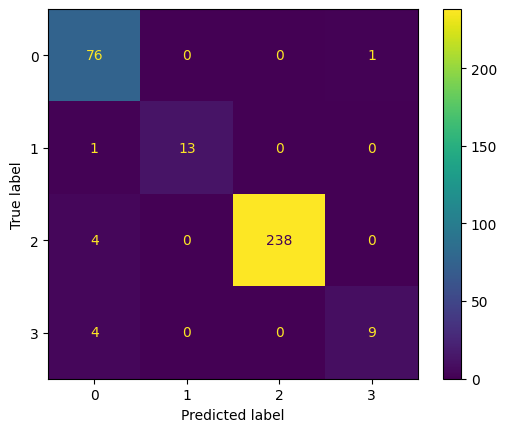

In [77]:
# Generate predictions with the best model
y_pred = best_rf.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", f"{accuracy:.4f}")
print("Precision:", f"{precision:.4f}")
print("Recall:", f"{recall:.4f}")

Accuracy: 0.9711
Precision: 0.9727
Recall: 0.9711


<Axes: >

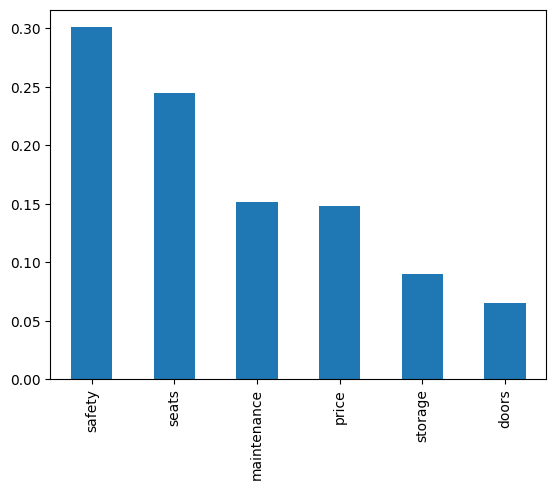

In [51]:
importances = pd.Series(best_rf.feature_importances_, index=cars.iloc[:, :-1].columns)
importances.sort_values(ascending=False).plot.bar()

### When to Use Random Forests (and When Not To)
Random Forests are a great choice when you need a strong baseline model that works well out of the box. They handle both numerical and categorical features, manage missing values gracefully, and are less prone to overfitting than single decision trees.

Use Random Forests when:

- You have tabular data with mixed feature types
- You want a robust model without heavy feature scaling or preprocessing
- Interpretability (via feature importance) matters for your application